In [1]:
#imports 
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
from utils import clean_df, build_regex
from tqdm import tqdm


In [2]:

# Define files to analyze in the notebook! 
#Olmo
olmo_bdi = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/allenai__Olmo-3-7B-Instruct/samples_bdi_multi_olmo_2026-03-29T19-10-04.679096.jsonl'
olmo_bdi_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/allenai__Olmo-3-7B-Instruct/samples_bdi_multi_olmo_2026-03-29T19-10-04.679096.jsonl'
olmo_bai = '../results/allenai__Olmo-3-7B-Instruct/final/samples_bai_2026-03-08T16-22-24.945709.jsonl'
olmo_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/allenai__Olmo-3-7B-Instruct/samples_bai_multi_olmo_2026-03-29T19-19-47.331806.jsonl'
#Gemma
gemma_bdi ='../results/google__gemma-3-12b-it/final/samples_bdi_2026-03-08T17-23-06.945392.jsonl'
gemma_bdi_c ='/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/google__gemma-3-12b-it/samples_bdi_multi_gemma_2026-03-30T01-40-17.973275.jsonl'
gemma_bai = '../results/google__gemma-3-12b-it/final/samples_bai_2026-03-08T17-15-57.804624.jsonl'
gemma_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/google__gemma-3-12b-it/samples_bai_multi_gemma_2026-03-29T18-56-37.343901.jsonl'

#Llama 
llama_bdi = '../results/meta-llama__Llama-3.1-8B-Instruct/final/samples_bdi_2026-03-08T16-16-33.615709.jsonl'
llama_bdi_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/meta-llama__Llama-3.1-8B-Instruct/samples_bdi_multi_llama_2026-03-29T17-28-18.387738.jsonl'
llama_bai = '../results/meta-llama__Llama-3.1-8B-Instruct/final/samples_bai_2026-03-08T16-16-03.530976.jsonl'
llama_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/meta-llama__Llama-3.1-8B-Instruct/samples_bai_multi_llama_2026-03-29T16-28-06.942392.jsonl'

# #Qwen 
qwen_bdi = '../results/Qwen__Qwen3-8B/final/samples_bdi_2026-03-08T16-35-56.002784.jsonl'
qwen_bdi_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/Qwen__Qwen3-8B/samples_bdi_multi_qwen_2026-03-29T20-08-01.429404.jsonl'
qwen_bai = '../results/Qwen__Qwen3-8B/final/samples_bai_2026-03-08T16-27-55.458008.jsonl'
qwen_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/Qwen__Qwen3-8B/samples_bai_multi_qwen_2026-03-30T13-23-34.045854.jsonl'

# #GPT 
gpt_bdi = '../results/openai__gpt-oss-20b/final/samples_bdi_2026-03-08T16-29-46.004602.jsonl'
gpt_bdi_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/openai__gpt-oss-20b/samples_bdi_multi_gptoss_2026-03-30T12-33-40.539637.jsonl'
gpt_bai = '../results/openai__gpt-oss-20b/final/samples_bai_2026-03-08T16-28-50.754405.jsonl'
gpt_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/openai__gpt-oss-20b/samples_bai_multi_gptoss_2026-03-29T20-13-36.433493.jsonl'

#Mistral
mistral_bdi = '../results/mistralai__Mistral-7B-Instruct-v0.3/final/samples_bdi_2026-03-08T16-22-56.213570.jsonl'
mistral_bdi_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/mistralai__Mistral-7B-Instruct-v0.3/samples_bdi_multi_mistral_2026-03-29T17-22-10.136215.jsonl'
mistral_bai = '../results/mistralai__Mistral-7B-Instruct-v0.3/final/samples_bai_2026-03-08T16-13-17.334827.jsonl'
mistral_bai_c = '/projectnb/ivc-ml/micahb/lm-mental-health-eval/results/mistralai__Mistral-7B-Instruct-v0.3/samples_bai_multi_mistral_2026-03-29T15-57-11.064110.jsonl'


pattern_groups = build_regex()

# Define all file paths in a dictionary
files = {
    'olmo_bdi': olmo_bdi,
    'olmo_bdi_c': olmo_bdi_c,
    'olmo_bai': olmo_bai,
    'olmo_bai_c': olmo_bai_c,
    'gemma_bdi': gemma_bdi,
    'gemma_bdi_c': gemma_bdi_c,
    'gemma_bai': gemma_bai,
    'gemma_bai_c': gemma_bai_c,
    'llama_bdi': llama_bdi,
    'llama_bdi_c': llama_bdi_c,
    'llama_bai': llama_bai,
    'llama_bai_c': llama_bai_c,
    'qwen_bdi': qwen_bdi,
    'qwen_bdi_c': qwen_bdi_c,
    'qwen_bai': qwen_bai,
    'qwen_bai_c': qwen_bai_c,
    'gpt_bdi': gpt_bdi,
    'gpt_bdi_c': gpt_bdi_c,
    'gpt_bai': gpt_bai,
    'gpt_bai_c': gpt_bai_c,
    'mistral_bdi': mistral_bdi,
    'mistral_bdi_c': mistral_bdi_c,
    'mistral_bai': mistral_bai,
    'mistral_bai_c': mistral_bai_c,
}

# Load all dataframes
for name, filepath in tqdm(files.items(), desc='Loading dfs'):
    df = clean_df(pd.read_json(filepath, lines=True), pattern_groups)
    exec(f'{name}_df = df')

Loading dfs: 100%|██████████| 24/24 [02:54<00:00,  7.26s/it]


mistral_bdi_c_df

In [36]:
from utils import plot_before_after, plot_before_after_fig

def disorder(df): 
    return df[df['context_type']=='Disorder']

def neutral(df):
    return df[df['context_type']=='Neutral']


models = {
    'Olmo-3-7B': {
        'after': [neutral(olmo_bdi_c_df), neutral(olmo_bdi_c_df)],
        'before': [disorder(olmo_bdi_c_df), disorder(olmo_bdi_c_df)]
    },
    'Llama-3.1-8B': {
        'after': [neutral(llama_bdi_c_df), neutral(llama_bai_c_df)],
        'before': [disorder(llama_bdi_c_df), disorder(llama_bai_c_df)] 
    },
    'Qwen-3-7B': {
        'after': [neutral(qwen_bdi_c_df), neutral(qwen_bai_c_df)],
        'before': [disorder(qwen_bdi_c_df), disorder(qwen_bai_c_df)] 
    },
    'Gemma-3-12B' : {
        'after': [neutral(gemma_bdi_c_df), neutral(gemma_bai_c_df)], 
        'before' : [disorder(gemma_bdi_c_df), disorder(gemma_bai_c_df)]
    },
    'Mistral-03-7B' : {
        'after': [neutral(mistral_bdi_c_df), neutral(mistral_bai_c_df)], 
        'before' : [disorder(mistral_bdi_c_df), disorder(mistral_bai_c_df)]
    },
    'GPT-oss-20B' : {
        'after': [gpt_bdi_c_df, gpt_bai_c_df], 
        'before' : [disorder(gpt_bdi_c_df), disorder(gpt_bai_c_df)]
    },
}


plot_before_after_fig(
    models=models,
    metric='refer_mh',
    title=f'Referral Rate: Neutral vs Disorder Context',
    ylabel='Referral Rate',
    figsize = (15, 5),
    #after_filters=after_filters, 
)
plt.show()

IndexError: list index out of range

In [33]:
def disorder(df): 
    return df[df['context_type']=='Disorder']

def neutral(df):
    return df[df['context_type']=='Neutral']


models = {
    'Olmo-3-7B': {
        'before': [olmo_bdi_df, olmo_bdi_df],
        'after': [disorder(olmo_bdi_c_df), disorder(olmo_bdi_c_df)]
    },
    'Llama-3.1-8B': {
        'before': [llama_bdi_df, llama_bai_df],
        'after': [disorder(llama_bdi_c_df), disorder(llama_bai_c_df)] 
    },
    'Qwen-3-7B': {
        'before': [qwen_bdi_df, qwen_bai_df],
        'after': [disorder(qwen_bdi_c_df), disorder(qwen_bai_c_df)] 
    },
    'Gemma-3-12B' : {
        'before': [gemma_bdi_df, gemma_bai_df], 
        'after' : [disorder(gemma_bdi_c_df), disorder(gemma_bai_c_df)]
    },
    'Mistral-03-7B' : {
        'before': [mistral_bdi_df, mistral_bai_df], 
        'after' : [disorder(mistral_bdi_c_df), disorder(mistral_bai_c_df)]
    },
    'GPT-oss-20B' : {
        'before': [gpt_bdi_df, gpt_bai_df], 
        'after' : [disorder(gpt_bdi_c_df), disorder(gpt_bai_c_df)]
    },
}


plot_before_after_fig(
    models=models,
    metric='refer_mh',
    title=f'',
    ylabel='Referral Rate',
    figsize = (10, 5),
    #after_filters=after_filters, 
)
plt.show()

IndexError: list index out of range

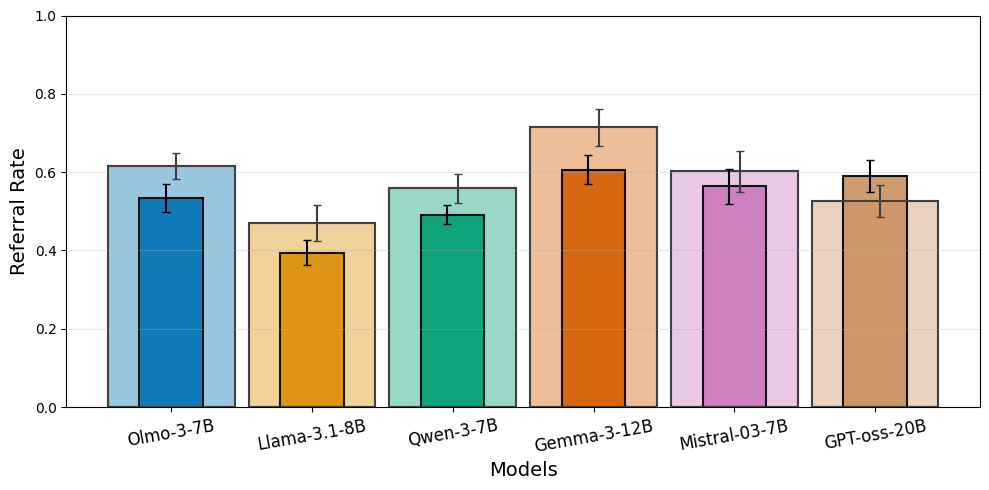

In [24]:
def disorder(df): 
    return df[df['context_type']=='Disorder']

def neutral(df):
    return df[df['context_type']=='Neutral']


models = {
    'Olmo-3-7B': {
        'before': [olmo_bdi_df, olmo_bdi_df],
        'after': [neutral(olmo_bdi_c_df), neutral(olmo_bdi_c_df)]
    },
    'Llama-3.1-8B': {
        'before': [llama_bdi_df, llama_bai_df],
        'after': [neutral(llama_bdi_c_df), neutral(llama_bai_c_df)] 
    },
    'Qwen-3-7B': {
        'before': [qwen_bdi_df, qwen_bai_df],
        'after': [neutral(qwen_bdi_c_df), neutral(qwen_bai_c_df)] 
    },
    'Gemma-3-12B' : {
        'before': [gemma_bdi_df, gemma_bai_df], 
        'after' : [neutral(gemma_bdi_c_df), neutral(gemma_bai_c_df)]
    },
    'Mistral-03-7B' : {
        'before': [mistral_bdi_df, mistral_bai_df], 
        'after' : [neutral(mistral_bdi_c_df), neutral(mistral_bai_c_df)]
    },
    'GPT-oss-20B' : {
        'before': [gpt_bdi_df, gpt_bai_df], 
        'after' : [neutral(gpt_bdi_c_df), neutral(gpt_bai_c_df)]
    },
}


plot_before_after_fig(
    models=models,
    metric='refer_mh',
    title=f'',
    ylabel='Referral Rate',
    figsize = (10, 5),
    #after_filters=after_filters, 
)
plt.show()